# NEISS Vitamin and Supplement ED Visit Analysis (Ollama + Statistical Patterns)

This notebook analyzes NEISS data to identify trends in emergency department visits related to vitamins and supplements. 

### Key Features:
1. **Ground Truth Comparison**: Labels cases based on product codes (1927, 1931, 1932).
2. **Statistical Word Analysis**: Automatically identifies words that distinguish supplements from non-supplements.
3. **Few-Shot Ollama Classification**: Uses the discovered words to guide a Llama model via Ollama for zero-manual-effort classification.
4. **Metric Validation**: Calculates accuracy and recall targeting >80% recall.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, re
import ollama
import os
from tqdm.auto import tqdm

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from collections import Counter

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading and Ground Truth labeling

We assign **Label 1** to product codes 1927, 1931, and 1932, and **Label 0** to all others.

In [2]:
file_path = 'PoisonedOnly_NEISS_2004-2023.xlsx'
print(f"Loading data from {file_path}...")

df = pd.read_excel(file_path, sheet_name='ALL (DO NOT EDIT)')
print(f"Loaded {len(df)} rows.")

Loading data from PoisonedOnly_NEISS_2004-2023.xlsx...
Loaded 91355 rows.


In [3]:
df.shape

(91355, 25)

In [4]:
df.dtypes

CPSC_Case_Number              int64
Treatment_Date       datetime64[us]
Age                           int64
Sex                           int64
Race                          int64
Other_Race                      str
Hispanic                    float64
Body_Part                     int64
Diagnosis                     int64
Other_Diagnosis             float64
Body_Part_2                 float64
Diagnosis_2                 float64
Other_Diagnosis_2               str
Disposition                   int64
Location                      int64
Fire_Involvement              int64
Product_1                     int64
Product_2                     int64
Product_3                     int64
Alcohol                     float64
Drug                        float64
Narrative                       str
Stratum                         str
PSU                           int64
Weight                      float64
dtype: object

In [5]:
# threshold = max unique values to consider categorical
threshold = 1000

cat_cols = []

for col in df.columns:
    if (
        df[col].dtype == 'object' or 
        df[col].dtype.name == 'category' or
        (df[col].dtype in ['int64','float64'] and df[col].nunique() < threshold)
    ):
        cat_cols.append(col)

print("Categorical columns detected:")
print(cat_cols)

Categorical columns detected:
['Age', 'Sex', 'Race', 'Hispanic', 'Body_Part', 'Diagnosis', 'Other_Diagnosis', 'Body_Part_2', 'Diagnosis_2', 'Disposition', 'Location', 'Fire_Involvement', 'Product_1', 'Product_2', 'Product_3', 'Alcohol', 'Drug', 'PSU', 'Weight']


In [6]:
# Ground Truth Definition
VITAMIN_CODES = [1927, 1931, 1932]

# check across all three product columns
df['Ground_Truth'] = (
    df[['Product_1','Product_2','Product_3']]
    .isin(VITAMIN_CODES)
    .any(axis=1)
    .astype(int)
)

# extract year
df['Treatment_Date'] = pd.to_datetime(df['Treatment_Date'])
df['Year'] = df['Treatment_Date'].dt.year

print(f"Loaded {len(df)} rows. Target class count: {df['Ground_Truth'].sum()}")

Loaded 91355 rows. Target class count: 27714


## 2. Statistical Word Analysis

Instead of hardcoding patterns, we find words that are statistically more frequent in the Target Class (Label 1) compared to the Non-Target Class (Label 0).

In [7]:
def get_word_freq(text_series):
    all_text = ' '.join(text_series.dropna().astype(str)).upper()
    words = re.findall(r'\b[A-Z]{3,}\b', all_text)  # ✅ correct word boundary
    counter = Counter(words)
    total = sum(counter.values())
    freqs = {w: c / total for w, c in counter.items()} if total > 0 else {}
    return freqs, counter

print("Analyzing word distributions...")
freq1, counts1 = get_word_freq(df[df['Ground_Truth'] == 1]['Narrative'])
freq0, counts0 = get_word_freq(df[df['Ground_Truth'] == 0]['Narrative'])

print("Vitamin class total tokens:", sum(counts1.values()))
print("Vitamin class max token count:", max(counts1.values()) if counts1 else 0)

# discriminative score (smoothed ratio)
min_count = 10
alpha = 1

scores = []
for word, c1 in counts1.items():
    if c1 >= min_count:
        c0 = counts0.get(word, 0)
        score = (c1 + alpha) / (c0 + alpha)
        scores.append((word, c1, c0, score))

scores.sort(key=lambda x: x[3], reverse=True)
top_supplement_words = [w for w, _, _, _ in scores[:20]]

print("Top words indicating a Supplement exposure:")
print(top_supplement_words)

Analyzing word distributions...
Vitamin class total tokens: 324865
Vitamin class max token count: 17340
Top words indicating a Supplement exposure:
['CHANNEL', 'IMMUNIZATION', 'PROPANOLOL', 'DRS', 'MINDER', 'VITAMINSDX', 'LEVOTHYROXINE', 'OMEPRAZOLE', 'DOCUSATE', 'PLANNER', 'ORGANIZER', 'MELATONIN', 'AZO', 'PANTOPRAZOLE', 'ATIN', 'BUPRENORPHINE', 'MCG', 'BIRTH', 'LOPERAMIDE', 'KCL']


## 3. Ollama Few-Shot Classification

We use the `ollama` library to classify narratives. The prompt is informed by our statistical analysis.

In [8]:
MODEL_NAME = "llama3.1:8b"

SYSTEM_MSG = """
You are a strict binary classifier for emergency department (ED) narratives.

OUTPUT FORMAT (must be valid JSON on a single line):
{"label": 0 or 1, "reason": "short reason"}

TASK:
Classify whether the narrative involves exposure/ingestion/overdose/adverse reaction to a VITAMIN or DIETARY SUPPLEMENT.

LABEL DEFINITIONS:
- label=1 ONLY if the narrative clearly involves a vitamin or dietary supplement AND it does NOT contain IRON.
  Examples (label=1): multivitamin WITHOUT iron, vitamin D, vitamin C gummies, melatonin gummies, herbal supplements, creatine, protein supplements.
- label=0 for EVERYTHING ELSE, including:
  - ANY product/formulation that contains IRON (including "iron", "Fe", "ferrous", "ferric", "ferro-", "prenatal with iron", "multivitamin with iron", "iron + vitamin C", "iron gummies", etc.)
  - Prescription (e.g., fexofenadine, Tylenol, cough medicine, antibiotics, “tabs” with no supplement mention)
  - Household chemicals/toxins (e.g., ammonia, detergent, bleach, windshield fluid)
  - Unknown ingestion where the substance is not clearly a vitamin/supplement

IRON EXCLUSION RULE (highest priority):
- If the narrative mentions IRON or an iron formulation (e.g., "iron", "Fe", "ferrous sulfate", "ferrous", "prenatal with iron", "iron gummies", "iron + vit C"),
  you MUST output label=0 even if it is a vitamin gummy or multivitamin.

GENERAL RULES:
- Do not guess. If supplement/vitamin is not explicit, choose 0.
- Ingestion alone does NOT imply label=1.
- Reason must cite the key phrase that triggered your decision.
""".strip()

# Few-shot examples WITH reasons (include hard negatives for iron exception)
FEW_SHOTS = [
    # Positives (supplements/vitamins WITHOUT iron)
    ("2 YOM INGESTED MULTIVITAMIN (NO IRON) GUMMIES.", 1, "Mentions 'multivitamin (no iron) gummies' which are supplements without iron."),
    ("CHILD TOOK SEVERAL VITAMIN D PILLS.", 1, "Explicit 'vitamin D' ingestion (no iron mentioned)."),
    ("ADULT TOOK MELATONIN GUMMIES; DIZZY.", 1, "Mentions 'melatonin gummies' (supplement; no iron)."),
    ("2YOF ATE VITAMIN C GUMMIES.", 1, "Mentions 'vitamin C gummies' (vitamin supplement; no iron)."),

    # Iron exception hard negatives (MUST be 0)
    ("2YOF ATE ADULT IRON + VIT C 18MG GUMMIES.", 0, "Mentions 'IRON + VIT C' / 'iron gummies' -> iron-containing formulation is excluded."),
    ("PT TOOK TOO MANY IRON SUPPLEMENTS.", 0, "Mentions 'iron supplements' -> iron-containing formulation is excluded."),
    ("PRENATAL VITAMINS WITH IRON INGESTION.", 0, "Mentions 'with iron' -> iron-containing formulation is excluded."),
    ("PT INGESTED FERROUS SULFATE TABLETS.", 0, "Mentions 'ferrous sulfate' -> iron formulation is excluded."),

    # Other hard negatives (non-supplement)
    ("10MOM GOT INTO A BOTTLE OF FEXOFENADINE TABLETS.", 0, "Fexofenadine is an OTC medication, not a supplement."),
    ("43YOF ALLERGIC RXN TO COUGH MED.", 0, "Cough medicine is medication, not a supplement."),
    ("PT DRANK 4-8 OZ OF WINDSHIELD FLUID.", 0, "Windshield fluid is a toxic chemical, not a supplement."),
    ("AMMONIA INGESTION - DRANK AMMONIA.", 0, "Ammonia is a household chemical, not a supplement."),
    ("2YOF ATE POWDERED LAUNDRY DETERGENT.", 0, "Laundry detergent is a chemical, not a supplement."),
]

def build_prompt(narrative: str):
    examples_block = "\n".join(
        [f'Narrative: {t}\nOutput: {json.dumps({"label": l, "reason": r})}'
         for t, l, r in FEW_SHOTS]
    )
    return f"""
    Classify the FINAL narrative.

    EXAMPLES:
    {examples_block}

    FINAL Narrative: {narrative}
    Output:
    """.strip()

def parse_json_output(text: str):
    text = text.strip()
    m = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not m:
        return None
    try:
        obj = json.loads(m.group(0))
        if "label" in obj and "reason" in obj and obj["label"] in [0, 1]:
            obj["reason"] = str(obj["reason"]).strip()
            return obj
    except Exception:
        return None
    return None

# Optional deterministic guardrail: iron keywords => label 0 (prevents LLM mistakes)
IRON_PAT = re.compile(r"\b(iron|fe|ferrous|ferric|ferro)\b", re.IGNORECASE)

def get_ollama_prediction_with_reason(narrative: str):
    # Hard rule: any iron mention => 0
    if IRON_PAT.search(narrative):
        return 0, "Mentions iron formulation (e.g., 'iron/Fe/ferrous'); iron-containing products are excluded."

    prompt = build_prompt(narrative)

    resp = ollama.chat(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": SYSTEM_MSG},
            {"role": "user", "content": prompt},
        ],
        options={"temperature": 0}
    )

    out = resp["message"]["content"]
    parsed = parse_json_output(out)

    # If format fails, retry once with stronger instruction
    if parsed is None:
        retry_prompt = prompt + '\n\nREMINDER: Output MUST be valid JSON: {"label":0 or 1, "reason":"..."}'
        resp2 = ollama.chat(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": SYSTEM_MSG},
                {"role": "user", "content": retry_prompt},
            ],
            options={"temperature": 0}
        )
        parsed = parse_json_output(resp2["message"]["content"])

    # Conservative final fallback (no guessing)
    if parsed is None:
        return 0, "Invalid model output; defaulted to 0 (do not guess)."

    return int(parsed["label"]), parsed["reason"]


In [9]:
print("Running Llama3.1:8b few-shot classification with reasons on a 10-sample toy dataset...")

# --- Balanced sample: 50% label 0 and 50% label 1 ---
n_total_toy = 10  # Toy example size
n_each_toy = n_total_toy // 2

df_0_toy = df[df["Ground_Truth"] == 0].sample(n_each_toy, random_state=42)
df_1_toy = df[df["Ground_Truth"] == 1].sample(n_each_toy, random_state=42)
df_toy = pd.concat([df_0_toy, df_1_toy]).sample(frac=1, random_state=42).reset_index(drop=True)

preds_toy = df_toy["Narrative"].apply(get_ollama_prediction_with_reason)

df_toy["Ollama_Label"] = preds_toy.apply(lambda x: x[0])
df_toy["Ollama_Reason"] = preds_toy.apply(lambda x: x[1])

display(df_toy[["Narrative", "Ground_Truth", "Ollama_Label", "Ollama_Reason"]])


Running Llama3.1:8b few-shot classification with reasons on a 10-sample toy dataset...


,Narrative,Ground_Truth,Ollama_Label,Ollama_Reason
0,2YOM TAKING AMOXICILLIN FOR AN OTITIS AND DEVE...,1,0,"Mentions 'amoxicillin' which is an antibiotic,..."
1,PT TOOK 2 *** LAST PM&ANOTHER ONE TODAY 7AM FO...,0,0,"No mention of vitamins or supplements, and the..."
2,SWALLOWED 1 OF FATHER'S *** TABLETS (20MG)DX: ...,1,0,Mentions 'TABLETS (20MG)' which is a medicatio...
3,44YOM REPORTS DOG SITTING WHEN DOG URINATED IN...,0,0,Mentions 'bleach' which is a household chemica...
4,2 YOM DRANK BOTTLE OF *** OPTHALMIC SOLUTION A...,1,0,Mentions 'ophthalmic solution' which is a medi...
5,"POISONING, PT INGESTED MEDICATED POWDER "" **"" ...",0,0,Mentions 'medicated powder' which is likely a ...
6,2YOM FND W BOTTLE DROPPER IN HIS MOUTH SUST WA...,1,0,No mention of vitamin or dietary supplement; m...
7,"68YOM, HX ATRIAL FLUTTER & SVT, HAS PALPITATIO...",0,0,No mention of vitamins or dietary supplements.
8,57 YO F ALCOHOL INTXICATION PT HAD BEEN DRINKI...,0,0,No mention of vitamins or supplements.
9,2 YOM DAD KNOCKED MOMS MEDICINE *** ONTO FLOOR...,1,0,Mentions 'medicine' which is likely a prescrip...


In [10]:
tqdm.pandas(desc="Classifying with Ollama")

print("Running Llama3.1:8b few-shot classification with reasons on 200 samples...")

# --- Balanced sample: 50% label 0 and 50% label 1 ---
n_total = 200 
n_each = n_total // 2

# Extract the samples
df_0 = df[df["Ground_Truth"] == 0].sample(n_each, random_state=42)
df_1 = df[df["Ground_Truth"] == 1].sample(n_each, random_state=42)
df_sample = pd.concat([df_0, df_1]).sample(frac=1, random_state=42).reset_index(drop=True)

# Use progress_apply instead of apply to see the progress bar!
preds = df_sample["Narrative"].progress_apply(get_ollama_prediction_with_reason)

# Save the results into the dataframe
df_sample["Ollama_Label"] = preds.apply(lambda x: x[0])
df_sample["Ollama_Reason"] = preds.apply(lambda x: x[1])


display_0 = df_sample[df_sample["Ground_Truth"] == 0].head(5)
display_1 = df_sample[df_sample["Ground_Truth"] == 1].head(5)
df_display = pd.concat([display_0, display_1])[["Narrative", "Ground_Truth", "Ollama_Label", "Ollama_Reason"]]
display(df_display)


Running Llama3.1:8b few-shot classification with reasons on 200 samples...


Classifying with Ollama: 100%|██████████| 200/200 [05:27<00:00,  1.64s/it]


,Narrative,Ground_Truth,Ollama_Label,Ollama_Reason
0,"PT FELL ASLEEP IN CHAIR, COCAINE,HEROIN ABUSE",0,0,No mention of vitamins or dietary supplements.
1,"2YOM, WHO BRUISES EASILY, HAS BRUISE ON CHIN A...",0,0,No mention of vitamins or dietary supplements;...
2,SWALLOWED HYDROGEN PEROXIDE ACCIDENTLY (THOUGH...,0,0,Mentions 'hydrogen peroxide' which is a househ...
6,15 YOF. ALTERED MENTAL STATUS AFTER DRINKING &...,0,0,No mention of vitamins or dietary supplements;...
9,33 YOM DRINKING FELL INTO GLASS CABINET. DX ET...,0,0,No mention of vitamins or supplements.
3,"23 MOM GOT INTO *** , 1/2 TABLET, VOMITED IMME...",1,0,No explicit mention of a vitamin or supplement...
4,"20MOF INGESTED SERTRALINE TABLETS OF MOM , FO...",1,0,Mentions 'sertraline tablets' which is a presc...
5,A 2 YR OLD MALE INGESTED A *** TABLET 12.5 MGD...,1,0,Mentions 'tablet' without specifying supplemen...
7,"19MOF SWOLLWED 5 *** PILLS, PT SHOWING NO SYMP...",1,0,Mentions 'pills' without specifying a suppleme...
8,13MO OLD F INGESTED **** PILLACCIDENTAL INGESTED,1,0,No explicit mention of a vitamin or supplement...


In [11]:
out_file = "NEISS_Supplement_200_Samples.xlsx"

with pd.ExcelWriter(out_file, engine="openpyxl") as writer:
    df_sample.to_excel(writer, sheet_name="sample_eval", index=False)

## 4. Final Metrics and Trends

Evaluating the performance and plotting the counts.

In [12]:
y_true = df_sample["Ground_Truth"].astype(int)
pred_col = "Ollama_Label" if "Ollama_Label" in df_sample.columns else "Ollama_Prediction"
y_pred = df_sample[pred_col].astype(int)


print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
print("--- Confusion Matrix ---")
print(f"True Negatives:  {cm[0][0]:<4} | False Positives: {cm[0][1]:<4}")
print(f"False Negatives: {cm[1][0]:<4} | True Positives:  {cm[1][1]:<4}\n")


Accuracy:  0.5050
Precision: 1.0000
Recall:    0.0100

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0     0.5025    1.0000    0.6689       100
           1     1.0000    0.0100    0.0198       100

    accuracy                         0.5050       200
   macro avg     0.7513    0.5050    0.3443       200
weighted avg     0.7513    0.5050    0.3443       200

--- Confusion Matrix ---
True Negatives:  100  | False Positives: 0   
False Negatives: 99   | True Positives:  1   



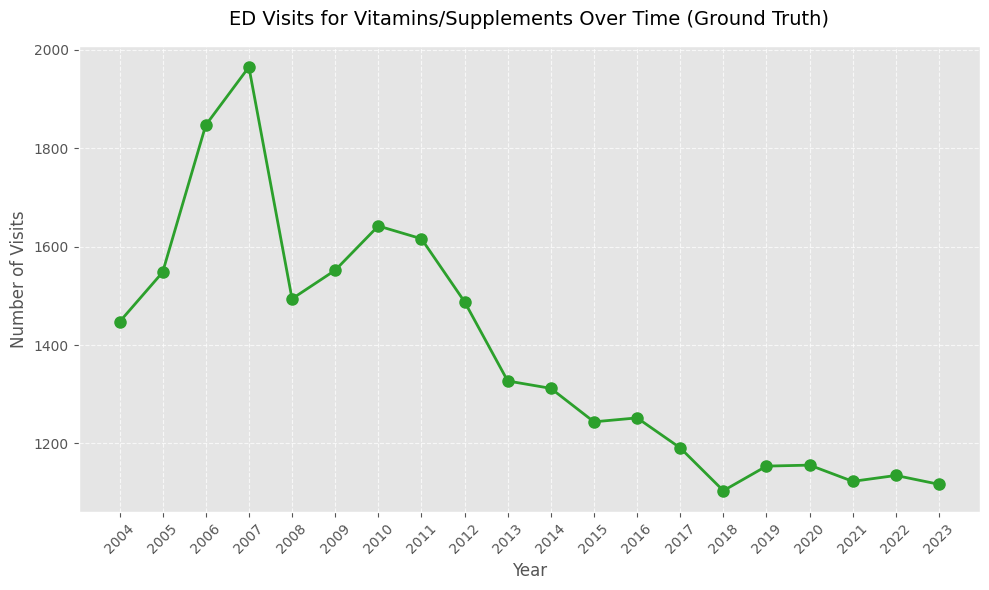

In [13]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

trend = (
    df.loc[df["Ground_Truth"] == 1]
      .dropna(subset=["Year"])
      .groupby("Year")
      .size()
      .sort_index()
)

plt.figure(figsize=(10, 6)) # Ingrandito per visibilità migliore

# Grafico a linea migliorato esteticamente
trend.plot(kind="line", marker="o", color="#2ca02c", linewidth=2, markersize=8)

plt.title("ED Visits for Vitamins/Supplements Over Time (Ground Truth)", fontsize=14, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Visits", fontsize=12)

# Set grid e ticks per migliore leggibilità
plt.xticks(trend.index, rotation=45)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()